## Build Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

np.random.seed(42)
n = 300

# Customer segmentation dataset
df = pd.DataFrame({
    'annual_income'   : np.concatenate([
        np.random.normal(30,  5, 100),
        np.random.normal(60,  8, 100),
        np.random.normal(100, 10, 100),
    ]),
    'spending_score'  : np.concatenate([
        np.random.normal(40,  8, 100),
        np.random.normal(50,  8, 100),
        np.random.normal(75, 10, 100),
    ]),
    'visit_frequency' : np.concatenate([
        np.random.normal(2, 1, 100).clip(0, 10),
        np.random.normal(5, 1, 100).clip(0, 10),
        np.random.normal(9, 1, 100).clip(0, 10),
    ])
})

# Scale data — just as important as K-Means
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Plot the dendrogram

Shape of linkage matrix: (299, 4)


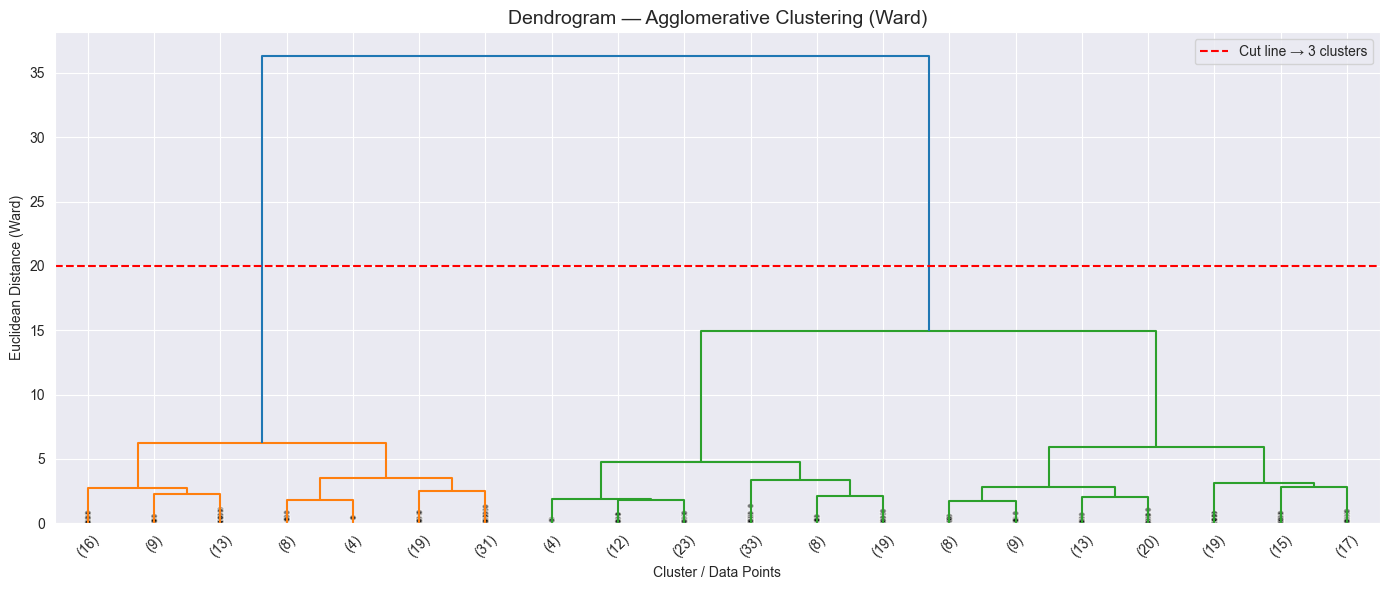

In [2]:
# scipy's linkage() computes the full merge history
# ward = linkage method (best default)
linked = linkage(X_scaled, method='ward')

# linked is a matrix where each row = one merge event
# columns: [cluster1, cluster2, distance, new_cluster_size]
print("Shape of linkage matrix:", linked.shape)
# (299, 4) → 299 merges for 300 points

plt.figure(figsize=(14, 6))

dendrogram(
    linked,
    truncate_mode    = 'lastp',
    # ↑ only show last p merges (avoid cluttered plot)
    p                = 20,
    # ↑ show last 20 merges only
    leaf_rotation    = 45,
    leaf_font_size   = 10,
    show_contracted  = True,
    # ↑ show a triangle for collapsed branches
)

plt.title("Dendrogram — Agglomerative Clustering (Ward)", fontsize=14)
plt.xlabel("Cluster / Data Points")
plt.ylabel("Euclidean Distance (Ward)")

# Draw a horizontal line to show where you'd cut
plt.axhline(y=20, color='red', linestyle='--', linewidth=1.5,
            label='Cut line → 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

# How to read this:
# Tall vertical lines = large distance between merged clusters
# Cut ACROSS the tallest lines to get natural clusters
# The number of lines you cross = number of clusters

## Find the optimal clusters vs silhouette

K=2  Silhouette: 0.6310
K=3  Silhouette: 0.5511
K=4  Silhouette: 0.4423
K=5  Silhouette: 0.3731
K=6  Silhouette: 0.3047
K=7  Silhouette: 0.2899
K=8  Silhouette: 0.2846


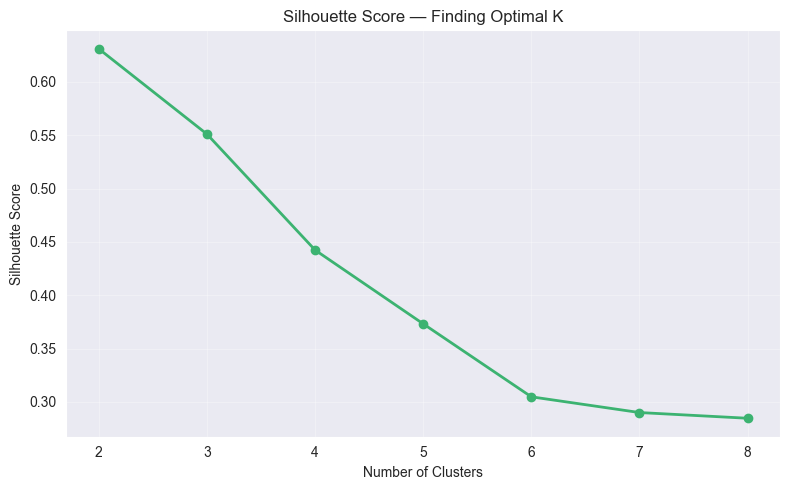

In [3]:
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    model  = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}  Silhouette: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o',
         color='mediumseagreen', linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Finding Optimal K")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fit the final model

In [4]:
agg = AgglomerativeClustering(
    n_clusters = 3,
    linkage    = 'ward',
    # ↑ ward: minimizes variance increase per merge
    #   best default — produces compact, balanced clusters

    metric     = 'euclidean',
    # ↑ distance metric used
    #   euclidean works with ward
    #   ward ONLY works with euclidean
    #   for other linkages can use: manhattan, cosine etc.
)

df['cluster'] = agg.fit_predict(X_scaled)
# fit_predict does fit + assign labels in one step
# returns array of cluster labels [0, 2, 1, 0, ...]

print("\nCluster counts:")
print(df['cluster'].value_counts())


Cluster counts:
cluster
1    101
0    100
2     99
Name: count, dtype: int64


## Analyze Clusters

In [5]:
print("\nCluster Profiles:")
print(df.groupby('cluster').mean().round(2))

#           annual_income  spending_score  visit_frequency
# cluster
# 0              30.1           40.2              2.0   ← Budget customers
# 1              60.0           49.9              5.0   ← Regular customers
# 2              99.8           74.9              9.1   ← Premium customers


Cluster Profiles:
         annual_income  spending_score  visit_frequency
cluster                                                
0               100.65           73.85             9.10
1                59.97           49.39             4.98
2                29.38           40.94             2.02


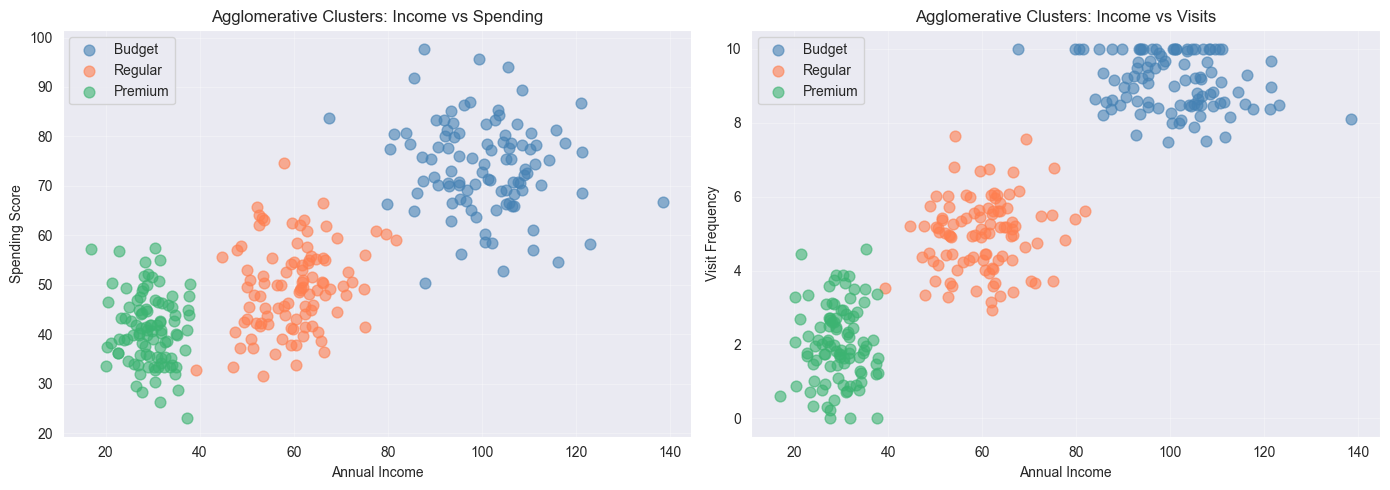

In [6]:
colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['Budget', 'Regular', 'Premium']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Income vs Spending
for cid in range(3):
    mask = df['cluster'] == cid
    axes[0].scatter(
        df[mask]['annual_income'],
        df[mask]['spending_score'],
        c=colors[cid], label=labels[cid],
        alpha=0.6, s=60
    )
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Spending Score")
axes[0].set_title("Agglomerative Clusters: Income vs Spending")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Income vs Visit Frequency
for cid in range(3):
    mask = df['cluster'] == cid
    axes[1].scatter(
        df[mask]['annual_income'],
        df[mask]['visit_frequency'],
        c=colors[cid], label=labels[cid],
        alpha=0.6, s=60
    )
axes[1].set_xlabel("Annual Income")
axes[1].set_ylabel("Visit Frequency")
axes[1].set_title("Agglomerative Clusters: Income vs Visits")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()